In [51]:
from Dataset.DataSetLoaders import ChessDataset
from PieceDetection.PieceDetection_CNN import PieceDetection_CNN
from PieceDetection.PieceCropper_3D import PieceCropper

import numpy as np
import torch
from torchvision import transforms

from matplotlib import pyplot as plt

from tqdm import tqdm

import os

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [52]:
model = PieceDetection_CNN.PieceDetectorCNNModel()
model.load_state_dict(torch.load("piece_cnn.pt"))

<All keys matched successfully>

In [53]:
def preprocess_fn(padding=(0,0)):
    # global lookup_quads
    def main(content):
        # global lookup_quads
        img, label = content
        
        # if not(str(label["id"]) in lookup_quads):
        #     BoardDetection.board_extractor.set_img(img)
        #     try:
        #         quad, conf = BoardDetection.board_extractor.extract_board()
        #     except Exception as e:
        #         quad = label["corners"].numpy().astype(np.float32)
        #         # plt.imshow(img.permute(1,2,0));
        #         # print(label)
        #         # raise e
        #     # warpped, M = BE.warp(quad, padding=padding)

        #     lookup_quads[str(label["id"])] = quad
        
        # quad = lookup_quads[str(label["id"])]
        quad = label["corners"].numpy().astype(np.float32)

        # orig_size = label["original_img_size"]
        orig_size = None

        PieceCropper.piece_cropper.set_img(img, torch.tensor(quad))
        board_split = PieceCropper.piece_cropper.process_img(original_img_size=orig_size)

        return board_split, label

    return main

In [54]:
ds = ChessDataset.ChessDataset(
    config={
        "img_size": (640,640)
    },
    img_label_transforms = transforms.Compose([
        preprocess_fn(),
    ]),
)

_, val_dataset, _ = ChessDataset.ChessDataset.train_valid_test_split(ds)

In [116]:
errs = []

cls_names = [
    "white-pawn",
    "white-knight",
    "white-bishop",
    "white-rook",
    "white-queen",
    "white-king",
    "black-pawn",
    "black-knight",
    "black-bishop",
    "black-rook",
    "black-queen",
    "black-king",
    "empty"
]

model.eval()
for idx in tqdm(range(len(val_dataset))):
    img, y = val_dataset[idx]

    with torch.inference_mode():
        preds = model(img.unsqueeze(0))

    occupancy: torch.Tensor = preds["occupancy"].reshape(-1)
    piece_color: torch.Tensor = preds["piece_color"].reshape(-1)
    piece_type: torch.Tensor = preds["piece_type"].reshape(-1,6)

    occupancy = occupancy.sigmoid()
    piece_color = piece_color.sigmoid()
    piece_type = piece_type.softmax(dim=1)

    res = torch.zeros(1*8*8, 13)
    res[:, 12] = 1-occupancy
    res[:, :6] = (
        piece_type * piece_color.unsqueeze(-1)) * occupancy.unsqueeze(-1)
    res[:, 6:12] = (
        piece_type * (1-piece_color).unsqueeze(-1)) * occupancy.unsqueeze(-1)

    res = res.reshape(1,8,8,13).permute(0, 3, 1, 2)
    matrix_pred = res.argmax(dim=1).squeeze()

    for i in range(8):
        for j in range(8):
            if matrix_pred[i,j] != y["board_tensor"][i,j]:
                tmp = res[0,:,i,j].tolist()
                tmp = {cls_names[idx]:val for idx,val in enumerate(tmp)}
                errs.append((idx, i, j, cls_names[matrix_pred[i,j]], cls_names[y["board_tensor"][i,j]], tmp))

100%|██████████| 99/99 [00:37<00:00,  2.67it/s]


In [117]:
len(errs)

345

In [118]:
i = 0

((0,
  3,
  4,
  'black-rook',
  'black-knight',
  {'white-pawn': 2.04749468935006e-07,
   'white-knight': 1.4217727766663302e-05,
   'white-bishop': 1.1479594164143236e-08,
   'white-rook': 9.357764793094248e-05,
   'white-queen': 9.99627047804097e-09,
   'white-king': 3.4000087190122485e-09,
   'black-pawn': 0.0018938869470730424,
   'black-knight': 0.13151080906391144,
   'black-bishop': 0.00010618368833092973,
   'black-rook': 0.8655723929405212,
   'black-queen': 9.246326953871176e-05,
   'black-king': 3.144932634313591e-05,
   'empty': 0.0006848573684692383}),
 '1r3k2/5p1p/2p1pp2/P2n4/2r1N3/P4PK1/2R2P1P/2R5 b - - 9 29',
 '/mnt/D/University/Thesis_Dataset/Dataset/Images/image_137.png')

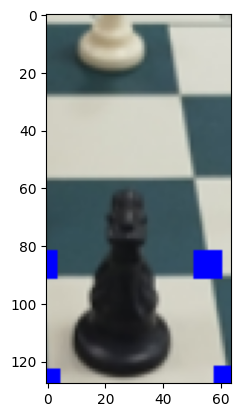

In [119]:
err = errs[i]
img, y = val_dataset[err[0]]
plt.imshow(img[err[1],err[2]].permute(1,2,0));
# plt.scatter(y["corners"][:,0], y["corners"][:,1]);
i += 1
err, y["fen"], y["image_path"]